In [2]:
import numpy as np, pandas as pd, tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense

In [4]:
# 1. 데이터 로드 (사인파 직접 만들기)

x = np.linspace(0, 50, 500)
data = np.sin(x).reshape(-1, 1)

In [5]:
train_size = int(len(data) * 0.8)
window = 15

train_data = data[:train_size]
test_data = data[train_size - window:]

In [6]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [7]:
def create_sequence(dataset, window_size):
    X, y = [], []
    for i in range(len(dataset) - window_size):
        X.append(dataset[i : i + window_size])
        y.append(dataset[i + window_size])
    return np.array(X), np.array(y)

X_train, y_train = create_sequence(train_scaled, window)
X_test, y_test = create_sequence(test_scaled, window)

In [9]:
model = Sequential([
    SimpleRNN(32, input_shape=(window, 1)),
    Dense(1)
])

In [10]:
model.compile(optimizer='adam', loss='mse')\

model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2578
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0246
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0056
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0025
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020 
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013 
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0010 
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.5635e-04
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1014e-04 
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.4725e-04 
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.4085e-04 
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8421e-04
Epoch 15/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


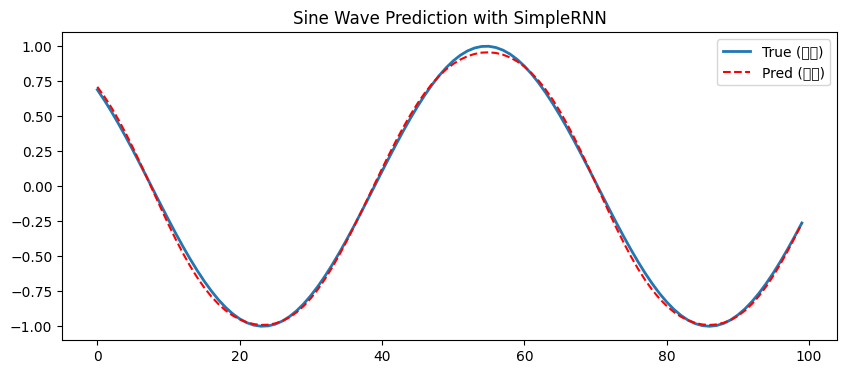

In [11]:
pred = model.predict(X_test)

plt.figure(figsize=(10, 4))
# 압축했던 숫자를 다시 원래 사인파 크기(-1~1)로 복구해서 그립니다.
plt.plot(scaler.inverse_transform(y_test), label='True (정답)', linewidth=2)
plt.plot(scaler.inverse_transform(pred), label='Pred (예측)', linestyle='--', color='red')
plt.title('Sine Wave Prediction with SimpleRNN')
plt.legend()
plt.show()